# NB01 — Topic Map: where biology lives, who funds it, where overlap creates synergy

Builds on NB00's tenant × topic cross-tab to answer:

1. **Agency view.** Which topics does each funding agency cover? Where do agencies overlap?
2. **Topic concentration.** For each biological topic, how concentrated is the data in a single tenant vs spread across many? (Concentration = single-owner risk; spread = cross-tenant join opportunity.)
3. **Synergy capacity.** Which tenants cover the broadest topic surface? These are the tenants most likely to anchor cross-agency analyses.

Audience: **KBase users** (where to look for what), **PIs / funders** (where coverage already exists vs. where investment would fill gaps).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv(PROJECT_ROOT / "data" / "table_topic_map.csv")
df["agency"] = df["agency"].fillna("Unknown")
print(f"Loaded {len(df)} tables, {df['tenant'].nunique()} tenants, {df['agency'].nunique()} agencies, {df['primary_topic'].nunique()} topics")

Loaded 1740 tables, 17 tenants, 11 agencies, 17 topics


## 1. Agency × topic — which agencies fund which biology

Rolled up from tenant to agency. Color = log-scaled table count (so DOE-BER does not visually swamp ARPA-H / NSF). Labels are absolute counts.

In [2]:
# Exclude 'unclassified' from the map — keep it as a separate residual view.
core = df[df["primary_topic"] != "unclassified"]

at = pd.crosstab(core["agency"], core["primary_topic"])
at = at.loc[at.sum(axis=1).sort_values(ascending=False).index]
at = at[at.sum(axis=0).sort_values(ascending=False).index]
at

primary_topic,field_observational,mobile_phage,fitness_phenotype,genome,integration,environment,taxonomy,multiomics,reference_protein,annotation,system,pangenome,literature,structural,pathway,biochemistry
agency,,,,,,,,,,,,,,,,
DOE-BER,601,4,115,42,30,63,31,37,46,26,5,23,24,22,11,10
Defense/HHS,0,242,0,0,0,0,0,0,0,0,0,0,0,0,0,0
User,25,0,62,46,20,0,2,0,0,2,1,0,0,0,0,0
ARPA-H,0,0,0,20,15,2,16,9,0,9,0,0,0,0,0,0
Multi,0,0,22,0,0,0,1,9,0,0,24,5,0,0,1,0
NSF,52,0,0,0,0,0,5,0,0,4,0,0,0,0,0,0
DOE/Academic,9,5,0,2,0,0,1,0,0,1,0,0,1,0,0,0
Academic,7,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0
DOE-FE,4,0,0,0,0,0,1,0,0,0,0,0,2,0,0,0


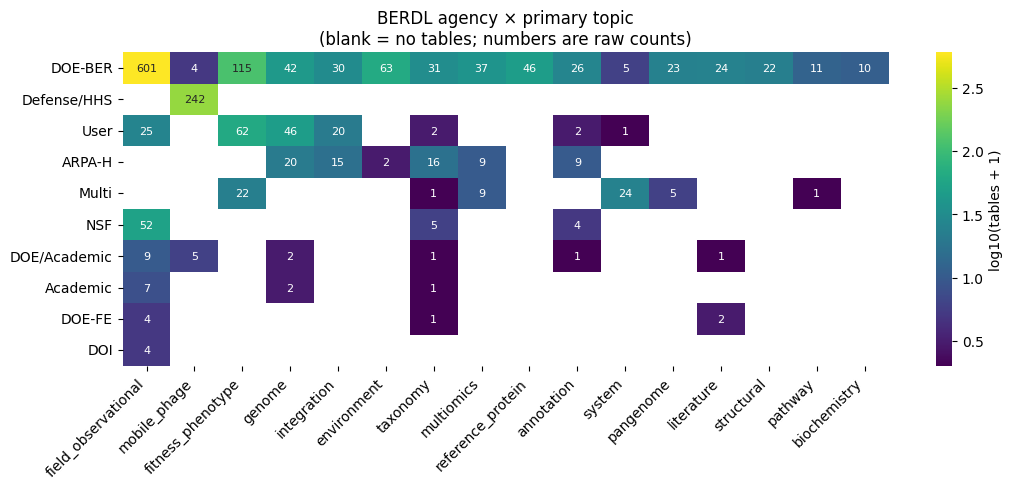

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
vals = at.values.astype(float)
norm = np.log10(vals + 1)
sns.heatmap(
    norm, ax=ax, cmap="viridis",
    annot=at.values, fmt="d", annot_kws={"size": 8},
    xticklabels=at.columns, yticklabels=at.index,
    cbar_kws={"label": "log10(tables + 1)"},
    mask=(at.values == 0),
)
ax.set_xticklabels(at.columns, rotation=45, ha="right")
ax.set_yticklabels(at.index, rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("BERDL agency × primary topic\n(blank = no tables; numbers are raw counts)")
fig.tight_layout()
fig.savefig(FIGURES / "nb01_agency_topic_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

## 2. Topic concentration — single-tenant vs cross-tenant topics

For each topic, what fraction of tables live in the **largest** tenant? A topic with 100% in one tenant = no cross-reference opportunity (within BERDL); a topic split across many tenants = high join potential.

Plot: horizontal stacked bar, one row per topic, segments = tenants, sorted by total tables.

In [4]:
tt = pd.crosstab(core["primary_topic"], core["tenant"])
tt = tt.loc[tt.sum(axis=1).sort_values(ascending=False).index]

# Concentration metric: share of largest tenant.
max_share = (tt.max(axis=1) / tt.sum(axis=1)).round(2)
n_tenants = (tt > 0).sum(axis=1)
conc = pd.DataFrame({
    "tables":      tt.sum(axis=1),
    "tenants":     n_tenants,
    "top_tenant":  tt.idxmax(axis=1),
    "top_share":   max_share,
})
conc.sort_values("tables", ascending=False)

,tables,tenants,top_tenant,top_share
primary_topic,,,,
field_observational,702,8,enigma,0.85
mobile_phage,251,3,phagefoundry,0.96
fitness_phenotype,199,5,kescience,0.52
genome,112,8,u,0.41
integration,65,4,ese,0.32
environment,65,3,nmdc,0.94
taxonomy,58,12,protect,0.28
multiomics,55,7,nmdc,0.35
reference_protein,46,3,refdata,0.78


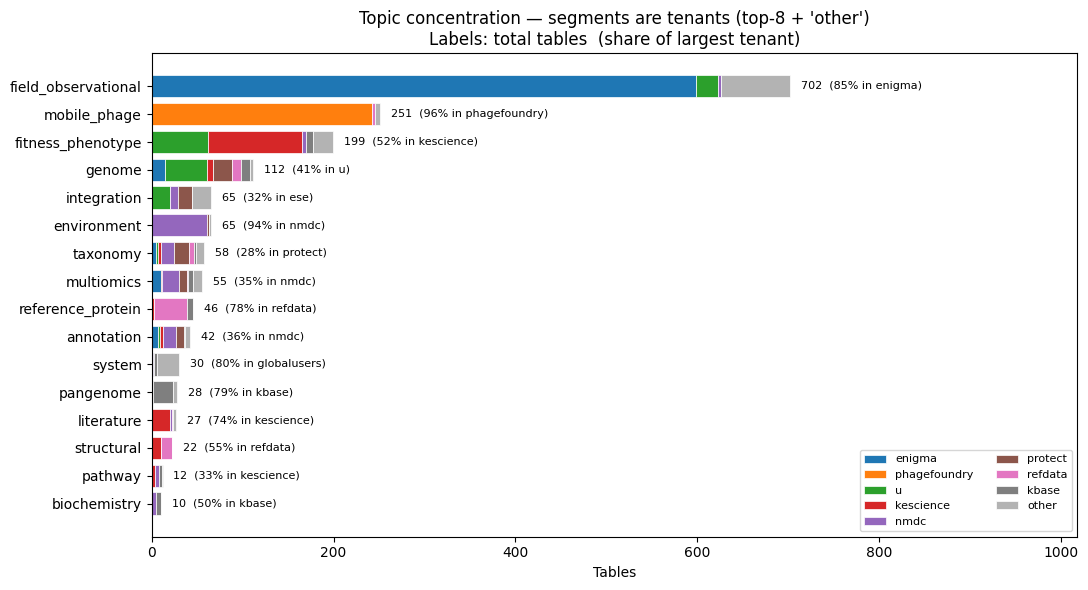

In [5]:
# Stacked bar: per topic, segment by tenant (top-8 tenants get colors, rest = grey)
top_tenants = tt.sum(axis=0).sort_values(ascending=False).head(8).index.tolist()
plot_tt = tt[top_tenants].copy()
plot_tt["other"] = tt.drop(columns=top_tenants).sum(axis=1)
plot_tt = plot_tt.loc[tt.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("tab10", n_colors=len(top_tenants)) + [(0.7, 0.7, 0.7)]
left = np.zeros(len(plot_tt))
for color, col in zip(palette, plot_tt.columns):
    vals = plot_tt[col].values
    ax.barh(plot_tt.index, vals, left=left, color=color, label=col, edgecolor="white", linewidth=0.5)
    left += vals

# Annotate top_share for each row.
totals = plot_tt.sum(axis=1).values
for i, (topic, total) in enumerate(zip(plot_tt.index, totals)):
    share = conc.loc[topic, "top_share"]
    ax.text(total + 12, i, f"{int(total)}  ({share*100:.0f}% in {conc.loc[topic, 'top_tenant']})",
            va="center", fontsize=8)

ax.set_xlabel("Tables")
ax.set_ylabel("")
ax.set_title("Topic concentration — segments are tenants (top-8 + 'other')\nLabels: total tables  (share of largest tenant)")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.set_xlim(0, totals.max() * 1.45)
fig.tight_layout()
fig.savefig(FIGURES / "nb01_topic_concentration.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. Synergy capacity — which tenants span the broadest topic surface

A tenant covering many topics is more likely to anchor a cross-program analysis (one tenant's data joins to many others' on shared topics). Two metrics:

- **distinct_topics**: how many primary topics the tenant covers (≥ 1 table).
- **topic_entropy** (Shannon, bits): how evenly the tenant's tables spread across topics. Higher = broader.

In [6]:
tenant_topic = pd.crosstab(core["tenant"], core["primary_topic"])
totals = tenant_topic.sum(axis=1)
p = tenant_topic.div(totals, axis=0)
with np.errstate(divide="ignore", invalid="ignore"):
    entropy_bits = -(p * np.log2(p)).fillna(0).sum(axis=1)

synergy = pd.DataFrame({
    "tables":          totals,
    "distinct_topics": (tenant_topic > 0).sum(axis=1),
    "topic_entropy":   entropy_bits.round(2),
}).sort_values(["distinct_topics", "topic_entropy"], ascending=False)
synergy

,tables,distinct_topics,topic_entropy
tenant,,,
nmdc,139,11,2.61
kescience,156,11,1.83
kbase,66,10,2.87
refdata,70,7,2.05
u,158,7,2.05
protect,71,6,2.37
arkinlab,19,6,2.03
globalusers,62,6,1.95
enigma,635,5,0.43


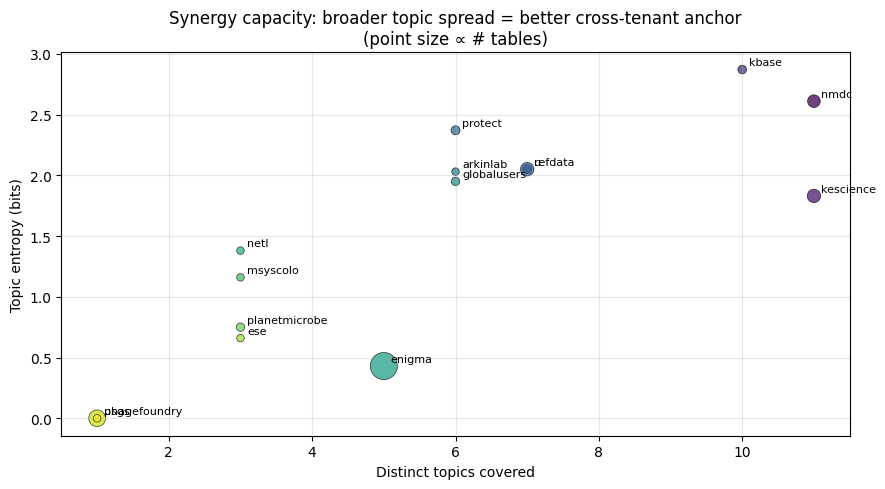

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sized = synergy.copy()
ax.scatter(
    sized["distinct_topics"], sized["topic_entropy"],
    s=np.clip(sized["tables"] * 0.6, 30, 500),
    c=range(len(sized)), cmap="viridis", alpha=0.75, edgecolor="black", linewidth=0.5,
)
for tenant, row in sized.iterrows():
    ax.annotate(
        tenant, (row["distinct_topics"], row["topic_entropy"]),
        xytext=(5, 3), textcoords="offset points", fontsize=8,
    )
ax.set_xlabel("Distinct topics covered")
ax.set_ylabel("Topic entropy (bits)")
ax.set_title("Synergy capacity: broader topic spread = better cross-tenant anchor\n(point size ∝ # tables)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / "nb01_synergy_capacity.png", dpi=140, bbox_inches="tight")
plt.show()

## 4. Findings

**Agency × topic coverage** (figure 1):
- **DOE-BER is the only broad-coverage funder** — it has tables in every primary topic (15/15). Its largest single column is `field_observational` (601 tables, almost all ENIGMA); the rest is spread across multi-omics, reference protein families, genomes, taxonomy, integration, annotation, literature, pangenome, structural, biochemistry, pathway.
- **Defense/HHS is mono-topic** — 242 tables, all `mobile_phage` (PhageFoundry). No native overlap with any other agency, which is exactly the cross-reference opportunity: PhageFoundry → DOE-BER taxonomy / pangenome / reference proteins via host genome IDs.
- **ARPA-H (PROTECT) spans 6 topics** — genome (20), taxonomy (16), integration (15), annotation (9), multi-omics (9), environment (2). Already wired for cross-reference into KBase + NMDC; the PROTECT MIND tables are the existing pattern.
- **NSF (Planet Microbe) is narrow** — `field_observational` (52) + taxonomy (5) + annotation (4). The join key into DOE-BER is sample/biosample metadata.
- **DOE-FE (NETL, 7 tables) and DOI (USGS, 4 tables)** are small footprints but cover unique sample types (produced waters) — high marginal value for environmental cross-reference even at low table count.

**Topic concentration** (figure 2):
- **Highly concentrated topics (>75% in one tenant)** — these are *reference resources*, single-owner by design; the synergy opportunity is *inbound* from other tenants:
  - `mobile_phage` (PhageFoundry 96%, 3 tenants)
  - `environment` (NMDC 94%, 3 tenants)
  - `field_observational` (ENIGMA 85%, 8 tenants)
  - `system` (globalusers 80%, 5 tenants)
  - `pangenome` (kbase 79%, 3 tenants)
  - `reference_protein` (refdata 78%, 3 tenants)
- **Cross-tenant topics (top tenant ≤ 55% share)** — these are the **natural join surfaces** between programs; an analysis anchored here automatically spans agencies:
  - `taxonomy` (protect 28%, **12 tenants**) — broadest cross-tenant surface in BERDL
  - `genome` (u 41%, 8 tenants) — note: "u" personal namespace tops this because each KBase Workspace genome appears as a per-user shadow table
  - `annotation` (nmdc 36%, 8 tenants)
  - `multiomics` (nmdc 35%, 7 tenants)
  - `integration` (ese 32%, 4 tenants)
  - `pathway` (kescience 33%, 4 tenants)
  - `fitness_phenotype` (kescience 52%, 5 tenants)
- **Moderately concentrated (60–75%)**: `literature` (kescience 74%), `biochemistry` (kbase 50%), `structural` (refdata 55%).

**Synergy capacity** (figure 3):
- **`kbase` (10 topics, entropy 2.87)** is the most evenly cross-topic tenant — it acts as the **biological reference hub** (biochemistry + pangenome + structural + pathway + genome + ontology).
- **`nmdc` (11 topics, entropy 2.61)** is the broadest-coverage tenant, with deep environmental / multi-omics / annotation / taxonomy reach.
- **`protect` (6 topics, entropy 2.37)** punches above its size — for 71 tables it covers genome + taxonomy + integration + annotation + multi-omics + environment, all the joins a pathogen-genomics analysis needs.
- **`kescience` (11 topics, entropy 1.83)** is the **knowledge-engine layer** — fitness, literature, pathway, biochemistry curation — but is dominated by FitnessBrowser, hence the lower entropy.
- **`enigma` (5 topics, entropy 0.43)** is the *deep but narrow* outlier — 635 tables, almost all `field_observational`. Best used as the field-data anchor that other programs cross-reference into.
- **`phagefoundry` and `usgs` are mono-topic** (entropy 0) — the synergy-capacity metric correctly identifies them as candidates for *outbound* cross-references rather than as hubs.

### Input for NB02 (linkage atlas)
The cross-tenant topics from §2 are the **prioritized join targets** for NB02. Concrete join keys to verify per-coverage across tenants:
- **Taxonomy** (12 tenants): `ncbi_taxon_id`, `gtdb_taxonomy`, `genus`, `species`
- **Genome** (8 tenants): `genome_id`, `assembly_accession`, `gcf`, `gca`
- **Annotation** (8 tenants): `kegg_ko`, `pfam_id`, `cog_category`, `ec_number`, `interpro_id`
- **Environment / sample** (NMDC + Planet Microbe + ENIGMA + NETL + USGS): `latitude`, `longitude`, `biosample_id`, `gold_id`, `envo_id`, `isolation_source`